# 17 — Preliminary check: richer store data → better beliefs → more profit?

## What this notebook does

This is a **small, cheap rehearsal** before larger cloud batch runs. It asks two
linked questions in about ten parallel jobs:

1. **Beliefs:** If the true shelf state is held fixed, does giving the filter
   **more store data** produce estimates that are closer to reality? (We score
   count and freshness error, not dollars.)
2. **Profit:** Under the same simulated week, does ordering with those data
   packages change **total profit** when the controller uses a simple
   base-stock policy (no forward simulation)?

We use a **short budget** (one shelf scenario, one random seed, only a few scored
days) to prove the cloud pipeline works — not to publish final value-of-information
numbers.

## Background: adding data step by step

Each row below is a **data package** — a bundle of fields the store might actually
have in its systems. We compare four packages in the profit section, plus a
hypothetical ceiling:

| Data package | What the store receives | Role in this notebook |
| --- | --- | --- |
| **Books only** | Register totals (sales in/out); no waste logging, no delivery paperwork | Baseline |
| **Books + waste scans** | Books plus scanned waste counts | First operational upgrade |
| **Pack date on advance notice** | Waste scans plus pack date on the ASN | Often strong for freshness estimates |
| **Temperature trace** | Lot-level detail plus cold-chain temperature history | Richest trace tested here |
| **Perfect information** | Hypothetical ceiling: controller sees true shelf state (not a real data feed) | Upper bound on profit |

**Part 1 (filter accuracy):** a diagnostic tool replays the **same ground-truth
week** under six data packages (the four above plus two intermediate lot-tracking
variants) and reports average error.

**Part 2 (profit):** the simulator runs a short scored week per package with
base-stock ordering only (no Monte Carlo rollout) and a pre-tuned smoothing
parameter from `experiments/tuned_alpha.json`.

## How to run

From the **repo root** (not `notebooks/`):

```bash
uv sync --python 3.11
cargo build -p voi_core --release --example gsin_upc_diag
uv run maturin build --release -m crates/voi_py/Cargo.toml -o dist/wheel
uv run jupyter lab notebooks/
```

- Default: `BATCH_MODE = "modal"` (needs a Modal account and built wheel + diagnostic binary).
- Laptop fallback: `BATCH_MODE = "local"` after `maturin develop`.
- **Restart the kernel** after rebuilding artifacts — Modal caches the image on first import.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import os
from pathlib import Path
from typing import Literal

import pandas as pd

REPO_ROOT = Path.cwd().resolve()
for _candidate in [REPO_ROOT, *REPO_ROOT.parents]:
    if (_candidate / "src" / "blueberries_voi").is_dir():
        REPO_ROOT = _candidate
        break

_wheel_dir = REPO_ROOT / "dist" / "wheel"
_gsin_bin = REPO_ROOT / "target" / "release" / "examples" / "gsin_upc_diag"
os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")
if _wheel_dir.is_dir():
    os.environ["BLUEBERRIES_VOI_WHEEL"] = str(_wheel_dir)
if _gsin_bin.is_file():
    os.environ["GSIN_UPC_DIAG_BIN"] = str(_gsin_bin)

from blueberries_voi.experiments.modal_dispatch import run_batch
from blueberries_voi.filter.types import channels_cache_key, channels_for_preset

# Plain-language labels for internal scenario codes (charts + tables only).
DATA_PACKAGE_LABELS: dict[str, str] = {
    "P0": "Books only",
    "P1": "Books + waste scans",
    "F1": "Lot-level sales & waste",
    "F2a": "Waste scans + pack date",
    "F2": "Lot detail + pack date",
    "F3": "Temperature trace",
    "B-state": "Perfect information (ceiling)",
}

BATCH_MODE: Literal["modal", "local"] = "modal"
SMOKE = False  # set True to shrink grids for a quicker plumbing check

# One filter-accuracy diagnostic job: mixed fleet, deep shelf scenario, first seed.
FILTER_DIAG_CELLS = [(2, 0)]
PROFIT_SEEDS = (42,)
# Internal preset ids → wired through channels_for_preset; labels are for display.
PROFIT_PRESET_IDS = ("P0", "P1", "F2a", "F3")
PROFIT_CHANNELS = [channels_for_preset(s) for s in PROFIT_PRESET_IDS]
PROFIT_LABELS = {
    channels_cache_key(ch): DATA_PACKAGE_LABELS[s]
    for s, ch in zip(PROFIT_PRESET_IDS, PROFIT_CHANNELS, strict=True)
}
N_BURN, N_SCORE = 2, 5

## Part 1 — How accurate is the filter? (one diagnostic run)

The filter-accuracy diagnostic keeps the **true shelf fixed** and asks: “If we only
allowed the filter to see data package *X*, how wrong would its beliefs be?” It
replays six packages (books-only through temperature trace) and prints one row per
package.

We launch **one cloud job** for a single shelf scenario (“mixed fleet, deep shelf”)
and one random seed — enough to see whether error falls as data gets richer before
paying for dozens of full-grid jobs.

**Metrics (lower is better):**
- `count_mae` — error in total on-shelf count belief
- `store_mean_f_mae` — error in mean freshness belief

In [2]:
filter_rows = run_batch(
    "gsin",
    BATCH_MODE,
    smoke=SMOKE,
    gsin_cells=FILTER_DIAG_CELLS,
)
filter_df = pd.DataFrame(filter_rows)
filter_df["data_package"] = filter_df["channel"].map(DATA_PACKAGE_LABELS)
filter_df[["regime", "data_package", "count_mae", "store_mean_f_mae"]]

[2026-08-24T17:17:56Z] nb13 grid: 1/1 complete


[2026-08-24T17:17:56Z] modal batch collected 1 shards


,regime,channel,count_mae,store_mean_f_mae
0,"Heterogeneous fleet, deep shelf",F1,202.4717,0.116217
1,"Heterogeneous fleet, deep shelf",F2,136.4630,0.072134
2,"Heterogeneous fleet, deep shelf",F2a,2.6778,0.023254
3,"Heterogeneous fleet, deep shelf",F3,1.2334,0.009527
4,"Heterogeneous fleet, deep shelf",P0,9.7006,0.088563
5,"Heterogeneous fleet, deep shelf",P1,5.2205,0.085136


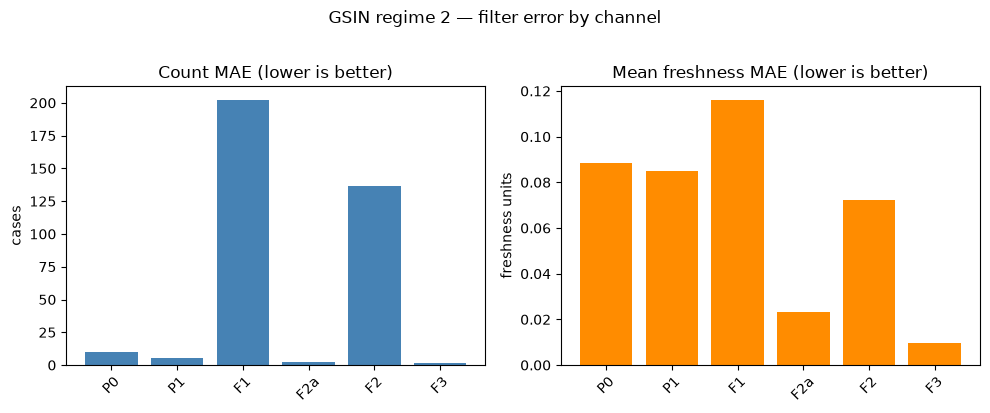

In [3]:
_DISPLAY_ORDER = [
    "Books only",
    "Books + waste scans",
    "Lot-level sales & waste",
    "Waste scans + pack date",
    "Lot detail + pack date",
    "Temperature trace",
]
plot_filter = (
    filter_df.set_index("data_package")
    .reindex([label for label in _DISPLAY_ORDER if label in filter_df["data_package"].values])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
axes[0].bar(plot_filter["data_package"], plot_filter["count_mae"], color="steelblue")
axes[0].set_title("Count error (lower is better)")
axes[0].set_ylabel("cases")
axes[1].bar(plot_filter["data_package"], plot_filter["store_mean_f_mae"], color="darkorange")
axes[1].set_title("Freshness error (lower is better)")
axes[1].set_ylabel("freshness units")
for ax in axes:
    ax.tick_params(axis="x", rotation=35, labelsize=8)
fig.suptitle("Filter accuracy by data package (one shelf scenario)", y=1.02)
fig.tight_layout()
plt.show()

### Part 1 — What we observed

In the **mixed fleet, deep shelf** scenario, filter accuracy does **not** improve
monotonically as data gets richer:

| Pattern | What the numbers show |
| --- | --- |
| **Freshness belief** | Error falls sharply once pack date appears on the advance notice (0.023), and is lowest with the **temperature trace** (0.010). Books-only error (0.089) is already moderate. |
| **Count belief** | Error is modest for books-only (9.7) and books + waste (5.2), but **spikes** for lot-level packages (136–202 cases). Lot tracking without the right delivery fields can confuse total-count inference. |
| **Takeaway** | Richer data can dramatically sharpen *freshness* estimates while *count* estimates get worse on some packages. That split matters because the ordering policy cares about both. |

These figures come from **one** shelf scenario and **one** random seed. They show the diagnostic pipeline works and hint at which data fields move beliefs — not a final ranking across all stores.

## Part 2 — Closed-loop profit (same data packages)

Here the filter **feeds the ordering policy** each day. We still use a tiny budget
(two warm-up days, five scored days, one random seed) but the score is **dollars**
(profit, waste, stockout) instead of belief error.

| Setting | Value | Why |
| --- | --- | --- |
| Policy | Base-stock only (no forward rollout) | Default production policy; isolates data value from simulation cost |
| Order smoothing | From `experiments/tuned_alpha.json` | Pre-tuned on a longer run |
| Ceiling row | Perfect-information scenario | Shows profit if beliefs were exact |

**What to look for:** profit is **not** guaranteed to track filter error. Better
beliefs can still yield similar orders, or profit can move because of demand and
spoilage while error barely changes.

In [4]:
profit_rows = run_batch(
    "voi_profit",
    BATCH_MODE,
    smoke=SMOKE,
    seeds=PROFIT_SEEDS,
    channels=PROFIT_CHANNELS,
    include_oracle=True,
    n_burn=N_BURN,
    n_score=N_SCORE,
    n_rollout_paths=0,
)
profit_df = pd.DataFrame(profit_rows)
profit_df["data_package"] = (
    profit_df["key"].map(PROFIT_LABELS)
    .fillna(profit_df.get("preset", "").map(DATA_PACKAGE_LABELS))
)
profit_df.groupby("data_package")[["profit", "waste", "stockout"]].mean().sort_values("profit")

[2026-08-24T17:18:09Z] nb13 grid: 1/5 complete


[2026-08-24T17:18:09Z] nb13 grid: 2/5 complete


[2026-08-24T17:18:09Z] nb13 grid: 3/5 complete


[2026-08-24T17:18:10Z] nb13 grid: 4/5 complete


[2026-08-24T17:18:12Z] nb13 grid: 5/5 complete


[2026-08-24T17:18:12Z] modal batch collected 5 shards


,profit,waste,stockout
label,,,
B-state,81.5,0.0,0.0
F2a,130.0,2.0,17.0
F3,130.0,2.0,17.0
P0,131.5,1.0,17.0
P1,131.5,1.0,17.0


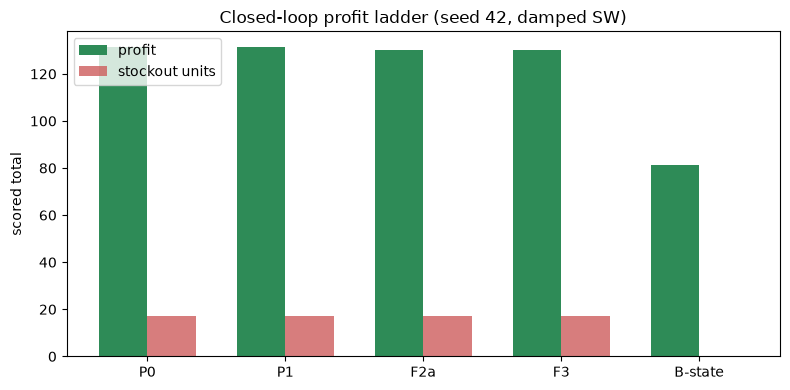

In [5]:
_PROFIT_ORDER = [
    "Books only",
    "Books + waste scans",
    "Waste scans + pack date",
    "Temperature trace",
    "Perfect information (ceiling)",
]
plot_profit = (
    profit_df.groupby("data_package")[["profit", "waste", "stockout"]]
    .mean()
    .reindex([label for label in _PROFIT_ORDER if label in profit_df["data_package"].values])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(plot_profit))
width = 0.35
ax.bar([i - width / 2 for i in x], plot_profit["profit"], width=width, label="profit", color="seagreen")
ax.bar([i + width / 2 for i in x], plot_profit["stockout"], width=width, label="stockout units", color="indianred", alpha=0.8)
ax.set_xticks(list(x), plot_profit["data_package"], rotation=20, ha="right")
ax.set_ylabel("scored total")
ax.set_title("Profit by data package (base-stock policy, one random seed)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

### Part 2 — What we observed

Over five scored days (seed 42), **profit barely separates** the four real data
packages:

| Data package | Profit | Waste | Stockout |
| --- | ---: | ---: | ---: |
| Books only | 131.5 | 1 | 17 |
| Books + waste scans | 131.5 | 1 | 17 |
| Pack date on advance notice | 130.0 | 2 | 17 |
| Temperature trace | 130.0 | 2 | 17 |
| Perfect information (ceiling) | 81.5 | 0 | 0 |

**Beliefs ≠ profit (again).** Part 1 showed the temperature trace has the sharpest
freshness estimates, yet it ties for **second-lowest** profit here. Books-only —
among the least informed packages on freshness — earns the most. The controller
can place similar orders despite very different beliefs, especially over a short
scored window.

**The ceiling row is not “max profit.”** Perfect information drives waste and
stockouts to zero but profit is **lower** (81.5) than the operational packages.
With exact shelf knowledge the policy may order differently enough that margin
over the five scored days suffers — the ceiling answers “how accurate can beliefs
be?” not “what is the best possible dollar outcome in every short episode.”

### Overall conclusion (this rehearsal)

1. **Pipeline:** filter diagnostic and profit jobs both completed in the cloud.
2. **Beliefs:** delivery paperwork (pack date, temperature) moves freshness error
   a lot; lot-level feeds can hurt count error in this scenario.
3. **Profit:** no clear dollar winner among the four packages at this budget —
   consistent with longer studies where data richness and profit decouple.
4. **Next step:** scale seeds, scenarios, and scored days before using these
   numbers for investment decisions.